# Resultados das buscas locais — TSP

Este notebook lê `resultados/resultados_tsp.csv` e compara Hill Climbing, Simulated Annealing e SA com Reaquecimento por tempo, custo e nós expandidos, apresentando média, desvio padrão e valores nas barras. Também mostra a distribuição das cidades e, para cada quantidade de cidades e algoritmo, o melhor e o pior caminho encontrado.


In [22]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

ARQUIVO_RESULTADOS = os.path.join(
    "resultados",
    "resultados_tsp.csv"
)

ARQUIVO_TSP = os.path.join(
    "problemas_json",
    "ulysses16.json"
)

df = pd.read_csv(ARQUIVO_RESULTADOS)

ordem_algoritmos = [
    "Hill Climbing",
    "Simulated Annealing",
    "SA com Reaquecimento"
]

df["algoritmo"] = pd.Categorical(
    df["algoritmo"],
    categories=ordem_algoritmos,
    ordered=True
)

df.head()


,quantidade_cidades,iteracao,execucao,algoritmo,seed,custo,tempo_ms,nos_expandidos,caminho,reaquecimentos
0,16,1,1,Hill Climbing,1038761579364415578,7551,1.9026,1260,"0,11,4,2,9,1,14,3,6,10,5,7,8,12,15,13,0;0,11,4...",0
1,16,1,1,Simulated Annealing,5505332158127348508,8303,2.0352,132,"0,11,4,2,9,1,14,3,6,10,5,7,8,12,15,13,0;0,11,4...",0
2,16,1,1,SA com Reaquecimento,7589208238346590110,6838,19.9723,1000,"0,11,4,2,9,1,14,3,6,10,5,7,8,12,15,13,0;0,11,1...",6
3,16,1,2,Hill Climbing,8838348332297520976,7075,2.0472,1260,"0,3,8,13,15,5,14,7,9,6,10,11,4,1,2,12,0;0,3,8,...",0
4,16,1,2,Simulated Annealing,759198346646428465,8461,2.1286,132,"0,3,8,13,15,5,14,7,9,6,10,11,4,1,2,12,0;0,3,8,...",0


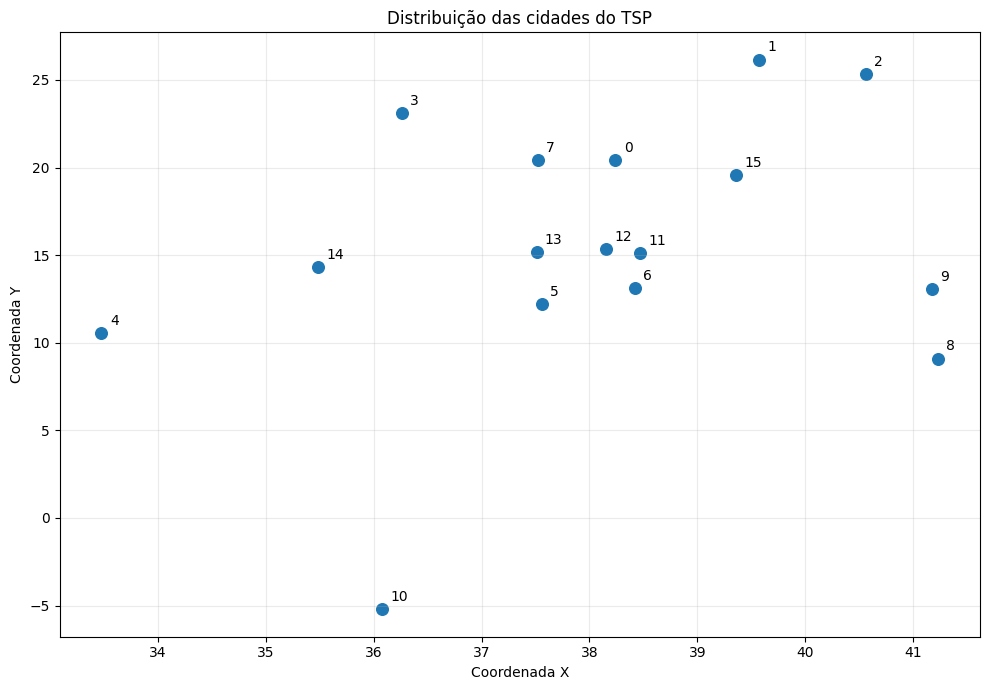

In [30]:
# ============================================================
# MAPA DAS CIDADES
# ============================================================

with open(ARQUIVO_TSP, "r", encoding="utf-8") as arquivo:
    tsp = json.load(arquivo)

coordenadas = tsp.get("coordinates")

if coordenadas is None:
    print("O arquivo TSP não possui coordenadas para plotagem.")
else:
    x = [cidade["x"] for cidade in coordenadas]
    y = [cidade["y"] for cidade in coordenadas]
    ids = [cidade.get("id", i) for i, cidade in enumerate(coordenadas)]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(x, y, s=70)

    for cidade_id, cx, cy in zip(ids, x, y):
        ax.annotate(
            str(cidade_id),
            (cx, cy),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10
        )

    ax.set_title("Distribuição das cidades do TSP")
    ax.set_xlabel("Coordenada X")
    ax.set_ylabel("Coordenada Y")
    # Com escala
    #ax.set_aspect("equal", adjustable="box")
    # Sem escala
    ax.set_aspect("auto")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


In [24]:
# ============================================================
# FUNÇÕES AUXILIARES PARA ESTATÍSTICAS
# ============================================================

def estatisticas_por_algoritmo(coluna):
    return (
        df.groupby(
            ["quantidade_cidades", "algoritmo"],
            observed=True
        )[coluna]
        .agg(["mean", "std"])
        .rename(columns={
            "mean": "media",
            "std": "desvio_padrao"
        })
        .unstack()
    )


def adicionar_rotulos_barras(ax):
    for container in ax.containers:
        if hasattr(container, "patches"):
            ax.bar_label(
                container,
                fmt="%.3g",
                padding=3,
                fontsize=9,
                rotation=90
            )


def mostrar_grafico(media, desvio, titulo, ylabel):
    media = media.reindex(columns=ordem_algoritmos)
    desvio = desvio.reindex(columns=ordem_algoritmos)

    ax = media.plot(
        kind="bar",
        figsize=(12, 6),
        yerr=desvio,
        capsize=4
    )

    ax.set_title(titulo)
    ax.set_xlabel("Quantidade de cidades")
    ax.set_ylabel(ylabel)
    ax.legend(title="Algoritmo")
    plt.xticks(rotation=0)
    adicionar_rotulos_barras(ax)
    plt.tight_layout()
    plt.show()


Média (ms)                                           \
algoritmo          Hill Climbing Simulated Annealing SA com Reaquecimento   
quantidade_cidades                                                          
2                        0.00150             0.00134              0.00324   
3                        0.00747             1.90845             13.59993   
4                        0.01012             1.93525             13.59962   
5                        0.01943             1.99015             13.74197   
6                        0.03221             1.94809             13.87367   
7                        0.05445             1.83848             14.02081   
8                        0.08570             1.83231             13.95661   
9                        0.14999             1.87282             14.04118   
10                       0.21011             1.87292             14.93543   
11                       0.29443             1.87145             14.35488   
12                       0.49457             1.90133             14.36042   
13                       0.74483             2.12704             14.99431   
14                       0.88900             1.98722             14.84321   
15                       1.37737             3.36486             19.11390   
16                       1.99914             2.79568             23.44781   

                   Desvio padrão (ms)                                           
algoritmo               Hill Climbing Simulated Annealing SA com Reaquecimento  
quantidade_cidades                                                              
2                            0.000254            0.001147             0.007224  
3                            0.003558            0.274207             0.267105  
4                            0.001832            0.104862             0.354816  
5                            0.002923            0.178692             0.270604  
6                            0.010910            0.044621             0.614611  
7                            0.016665            0.017496             0.284374  
8                            0.021027            0.020871             0.254607  
9                            0.051886            0.079630             0.289282  
10                           0.039368            0.031770             1.812442  
11                           0.042979            0.025333             0.287593  
12                           0.099577            0.051807             0.249659  
13                           0.213704            0.453597             1.160048  
14                           0.103070            0.203146             0.519445  
15                           0.368648            3.156996             6.211493  
16                           0.484097            0.971733            11.092133

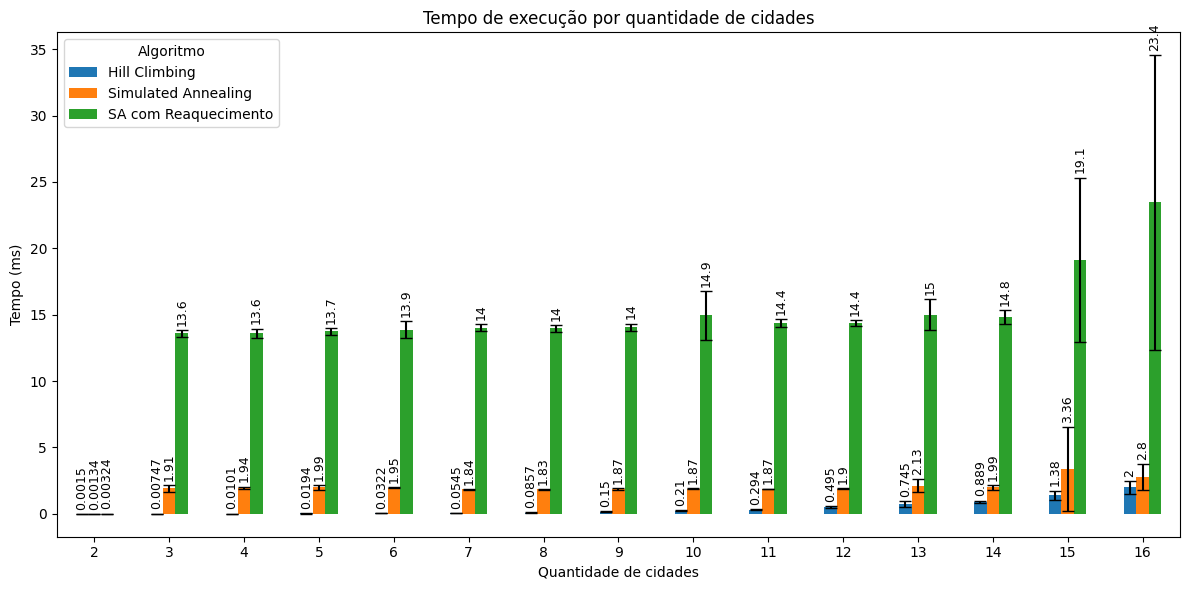

In [25]:
# ============================================================
# TEMPO: MÉDIA E DESVIO PADRÃO
# ============================================================

tempo_estatisticas = estatisticas_por_algoritmo("tempo_ms")
tempo_medio = tempo_estatisticas["media"].reindex(columns=ordem_algoritmos)
tempo_desvio = tempo_estatisticas["desvio_padrao"].reindex(columns=ordem_algoritmos)

display(pd.concat({
    "Média (ms)": tempo_medio,
    "Desvio padrão (ms)": tempo_desvio
}, axis=1))

mostrar_grafico(
    tempo_medio,
    tempo_desvio,
    "Tempo de execução por quantidade de cidades",
    "Tempo (ms)"
)


Média                                           \
algoritmo          Hill Climbing Simulated Annealing SA com Reaquecimento   
quantidade_cidades                                                          
2                         1018.0              1018.0               1018.0   
3                         1136.0              1136.0               1136.0   
4                         1413.0              1413.0               1413.0   
5                         3277.0              3277.0               3277.0   
6                         3472.0              3472.0               3472.0   
7                         3547.4              3561.8               3507.0   
8                         3635.0              3662.4               3580.4   
9                         4394.8              4406.1               4378.2   
10                        4452.1              4576.6               4381.8   
11                        6960.4              6892.5               6427.9   
12                        6913.8              7139.2               6531.0   
13                        7106.7              6994.1               6662.0   
14                        7103.8              7402.0               6926.5   
15                        7568.7              8033.5               7353.6   
16                        7344.3              8416.0               7166.5   

                   Desvio padrão                                           
algoritmo          Hill Climbing Simulated Annealing SA com Reaquecimento  
quantidade_cidades                                                         
2                       0.000000            0.000000             0.000000  
3                       0.000000            0.000000             0.000000  
4                       0.000000            0.000000             0.000000  
5                       0.000000            0.000000             0.000000  
6                       0.000000            0.000000             0.000000  
7                      52.156176          115.528544             0.000000  
8                      88.362888           81.819856             7.589466  
9                      23.131508           41.863402             9.704524  
10                     53.937103          119.798164             9.295160  
11                    641.404916          570.752184           105.174405  
12                    647.387880          510.873718            99.268435  
13                    662.963222          225.074037           255.108691  
14                    404.987462          608.602224           492.684540  
15                    471.208859          537.205785           456.349574  
16                    569.135026          378.143124           278.862471

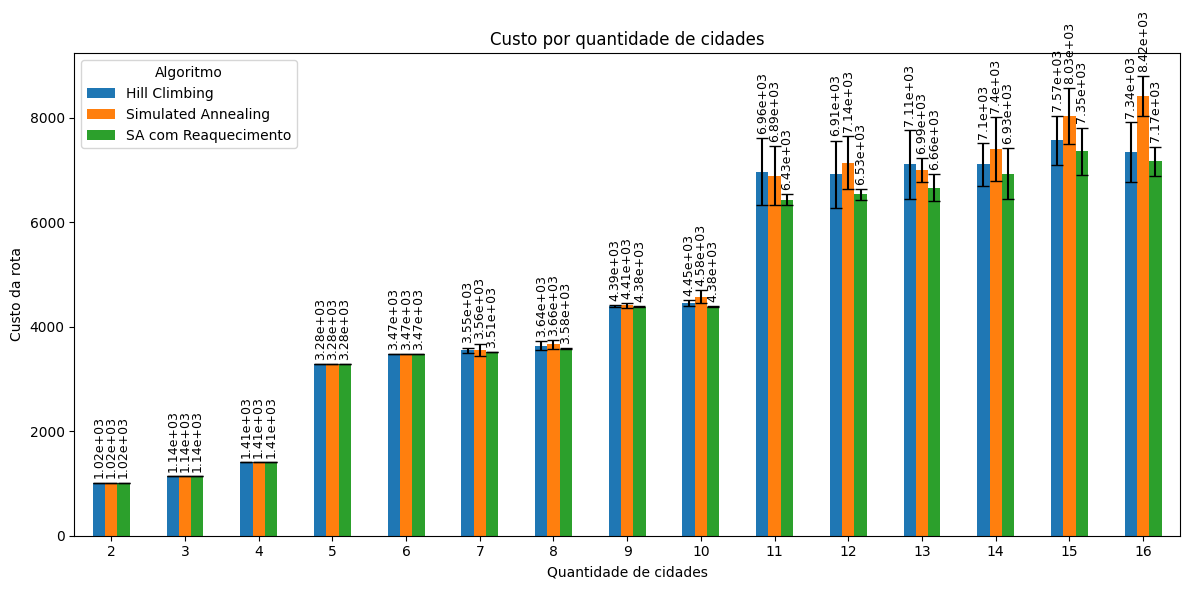

In [26]:
# ============================================================
# CUSTO: MÉDIA E DESVIO PADRÃO
# ============================================================

custo_estatisticas = estatisticas_por_algoritmo("custo")
custo_medio = custo_estatisticas["media"].reindex(columns=ordem_algoritmos)
custo_desvio = custo_estatisticas["desvio_padrao"].reindex(columns=ordem_algoritmos)

display(pd.concat({
    "Média": custo_medio,
    "Desvio padrão": custo_desvio
}, axis=1))

mostrar_grafico(
    custo_medio,
    custo_desvio,
    "Custo por quantidade de cidades",
    "Custo da rota"
)


Média                                           \
algoritmo          Hill Climbing Simulated Annealing SA com Reaquecimento   
quantidade_cidades                                                          
2                            0.0                 0.0                  0.0   
3                            1.0               132.0               1000.0   
4                            5.1               132.0               1000.0   
5                           14.4               132.0               1000.0   
6                           28.0               132.0               1000.0   
7                           52.5               132.0               1000.0   
8                           84.0               132.0               1000.0   
9                          142.8               132.0               1000.0   
10                         190.8               132.0               1000.0   
11                         256.5               132.0               1000.0   
12                         407.0               132.0               1000.0   
13                         501.6               132.0               1000.0   
14                         678.6               132.0               1000.0   
15                         828.1               132.0               1000.0   
16                        1113.0               132.0               1000.0   

                   Desvio padrão                                           
algoritmo          Hill Climbing Simulated Annealing SA com Reaquecimento  
quantidade_cidades                                                         
2                       0.000000                 0.0                  0.0  
3                       0.000000                 0.0                  0.0  
4                       1.449138                 0.0                  0.0  
5                       3.098387                 0.0                  0.0  
6                      10.327956                 0.0                  0.0  
7                      17.677670                 0.0                  0.0  
8                      22.135944                 0.0                  0.0  
9                      50.174806                 0.0                  0.0  
10                     34.152599                 0.0                  0.0  
11                     37.047267                 0.0                  0.0  
12                     82.804992                 0.0                  0.0  
13                    146.593315                 0.0                  0.0  
14                     82.629293                 0.0                  0.0  
15                    189.188589                 0.0                  0.0  
16                    253.357455                 0.0                  0.0

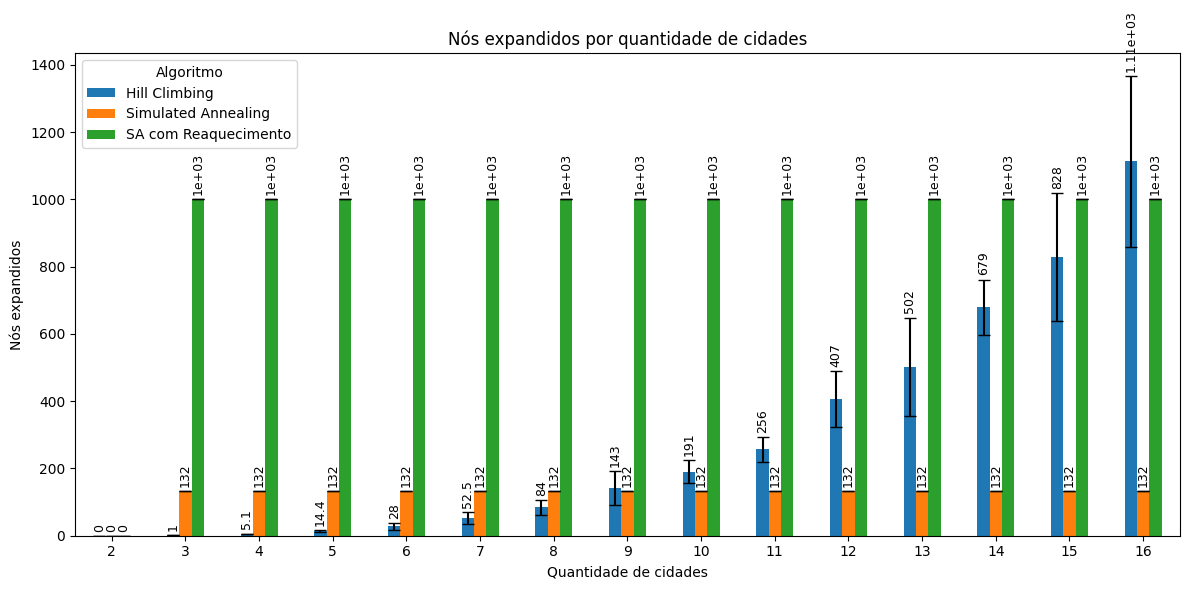

In [27]:
# ============================================================
# NÓS EXPANDIDOS: MÉDIA E DESVIO PADRÃO
# ============================================================

if "nos_expandidos" not in df.columns:
    print(
        "A coluna 'nos_expandidos' não existe no CSV. "
        "Execute o experimento com a versão que registra os nós expandidos."
    )
else:
    nos_estatisticas = estatisticas_por_algoritmo("nos_expandidos")
    nos_medio = nos_estatisticas["media"].reindex(columns=ordem_algoritmos)
    nos_desvio = nos_estatisticas["desvio_padrao"].reindex(columns=ordem_algoritmos)

    display(pd.concat({
        "Média": nos_medio,
        "Desvio padrão": nos_desvio
    }, axis=1))

    mostrar_grafico(
        nos_medio,
        nos_desvio,
        "Nós expandidos por quantidade de cidades",
        "Nós expandidos"
    )


In [28]:
# ============================================================
# MELHOR E PIOR CAMINHO DE CADA CASO
# ============================================================

if "caminho" not in df.columns:
    print(
        "A coluna 'caminho' não existe no CSV. "
        "Execute o experimento com a versão que registra o caminho."
    )
else:
    registros = []

    for quantidade in sorted(df["quantidade_cidades"].dropna().unique(), reverse=True):
        caso = df[df["quantidade_cidades"] == quantidade]

        for algoritmo in ordem_algoritmos:
            dados = caso[caso["algoritmo"] == algoritmo].dropna(subset=["custo"])

            if dados.empty:
                continue

            melhor = dados.loc[dados["custo"].idxmin()]
            pior = dados.loc[dados["custo"].idxmax()]

            registros.append({
                "Cidades": int(quantidade),
                "Algoritmo": algoritmo,
                "Melhor custo": melhor["custo"],
                "Melhor execução": int(melhor["execucao"]),
                "Melhor caminho": melhor["caminho"],
                "Pior custo": pior["custo"],
                "Pior execução": int(pior["execucao"]),
                "Pior caminho": pior["caminho"]
            })

    caminhos = pd.DataFrame(registros)

    if not caminhos.empty:
        display(caminhos)
    else:
        print("Não foram encontrados caminhos válidos no CSV.")


,Cidades,Algoritmo,Melhor custo,Melhor execução,Melhor caminho,Pior custo,Pior execução,Pior caminho
0,16,Hill Climbing,6763,6,"0,4,2,14,12,11,13,1,9,5,8,10,7,6,3,15,0;0,7,2,...",8412,8,"0,10,12,14,1,13,9,8,3,11,15,6,7,4,5,2,0;0,7,12..."
1,16,Simulated Annealing,7841,6,"0,4,2,14,12,11,13,1,9,5,8,10,7,6,3,15,0;0,4,2,...",9077,8,"0,10,12,14,1,13,9,8,3,11,15,6,7,4,5,2,0;0,10,1..."
2,16,SA com Reaquecimento,6838,1,"0,11,4,2,9,1,14,3,6,10,5,7,8,12,15,13,0;0,11,1...",7684,9,"0,6,1,10,9,7,12,11,14,3,4,13,8,5,2,15,0;0,6,1,..."
3,15,Hill Climbing,6888,5,"0,3,1,12,8,4,9,6,13,2,7,14,10,5,11,0;0,3,1,12,...",8061,7,"0,5,13,1,12,11,9,7,2,6,14,8,4,3,10,0;0,5,13,10..."
4,15,Simulated Annealing,6988,9,"0,14,12,4,13,2,8,1,10,5,3,7,9,6,11,0;0,13,12,4...",8745,1,"0,2,1,5,3,8,7,14,13,12,6,4,11,9,10,0;0,2,1,11,..."
5,15,SA com Reaquecimento,6755,8,"0,12,8,9,4,1,6,13,5,2,11,3,14,10,7,0;0,12,8,9,...",8029,3,"0,5,2,6,11,12,13,14,1,10,4,8,7,3,9,0;0,1,2,6,1..."
6,14,Hill Climbing,6452,10,"0,5,3,1,11,13,12,10,4,6,9,7,8,2,0;0,7,3,1,11,1...",7653,6,"0,3,12,10,6,7,2,11,9,1,5,8,13,4,0;0,3,12,10,6,..."
7,14,Simulated Annealing,6643,2,"0,8,13,1,12,3,4,5,6,9,2,10,11,7,0;0,8,13,1,3,1...",8355,9,"0,1,12,3,8,7,6,9,4,13,11,2,5,10,0;0,1,12,3,8,7..."
8,14,SA com Reaquecimento,6493,10,"0,5,3,1,11,13,12,10,4,6,9,7,8,2,0;0,5,3,1,11,1...",7726,3,"0,7,4,6,9,11,8,10,1,2,5,13,3,12,0;0,7,4,6,9,3,..."
9,13,Hill Climbing,6369,4,"0,9,7,11,1,12,10,6,8,3,5,2,4,0;0,9,7,11,5,12,1...",7986,7,"0,3,10,8,12,2,4,7,6,5,9,11,1,0;0,4,10,8,12,2,3..."
